### If you doubt, run the code!

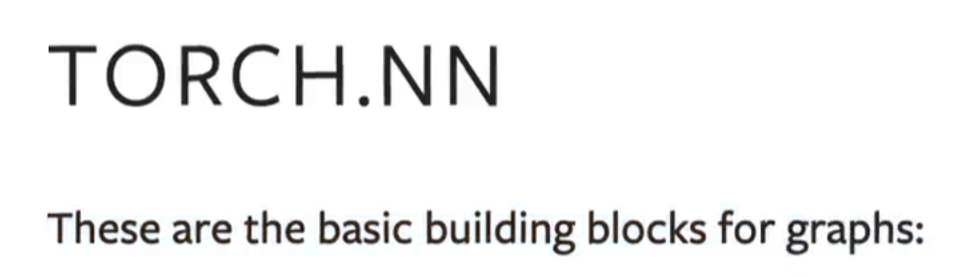

In [1]:
import torch
import torch.nn as nn 

torch.__version__

'2.4.1+cpu'

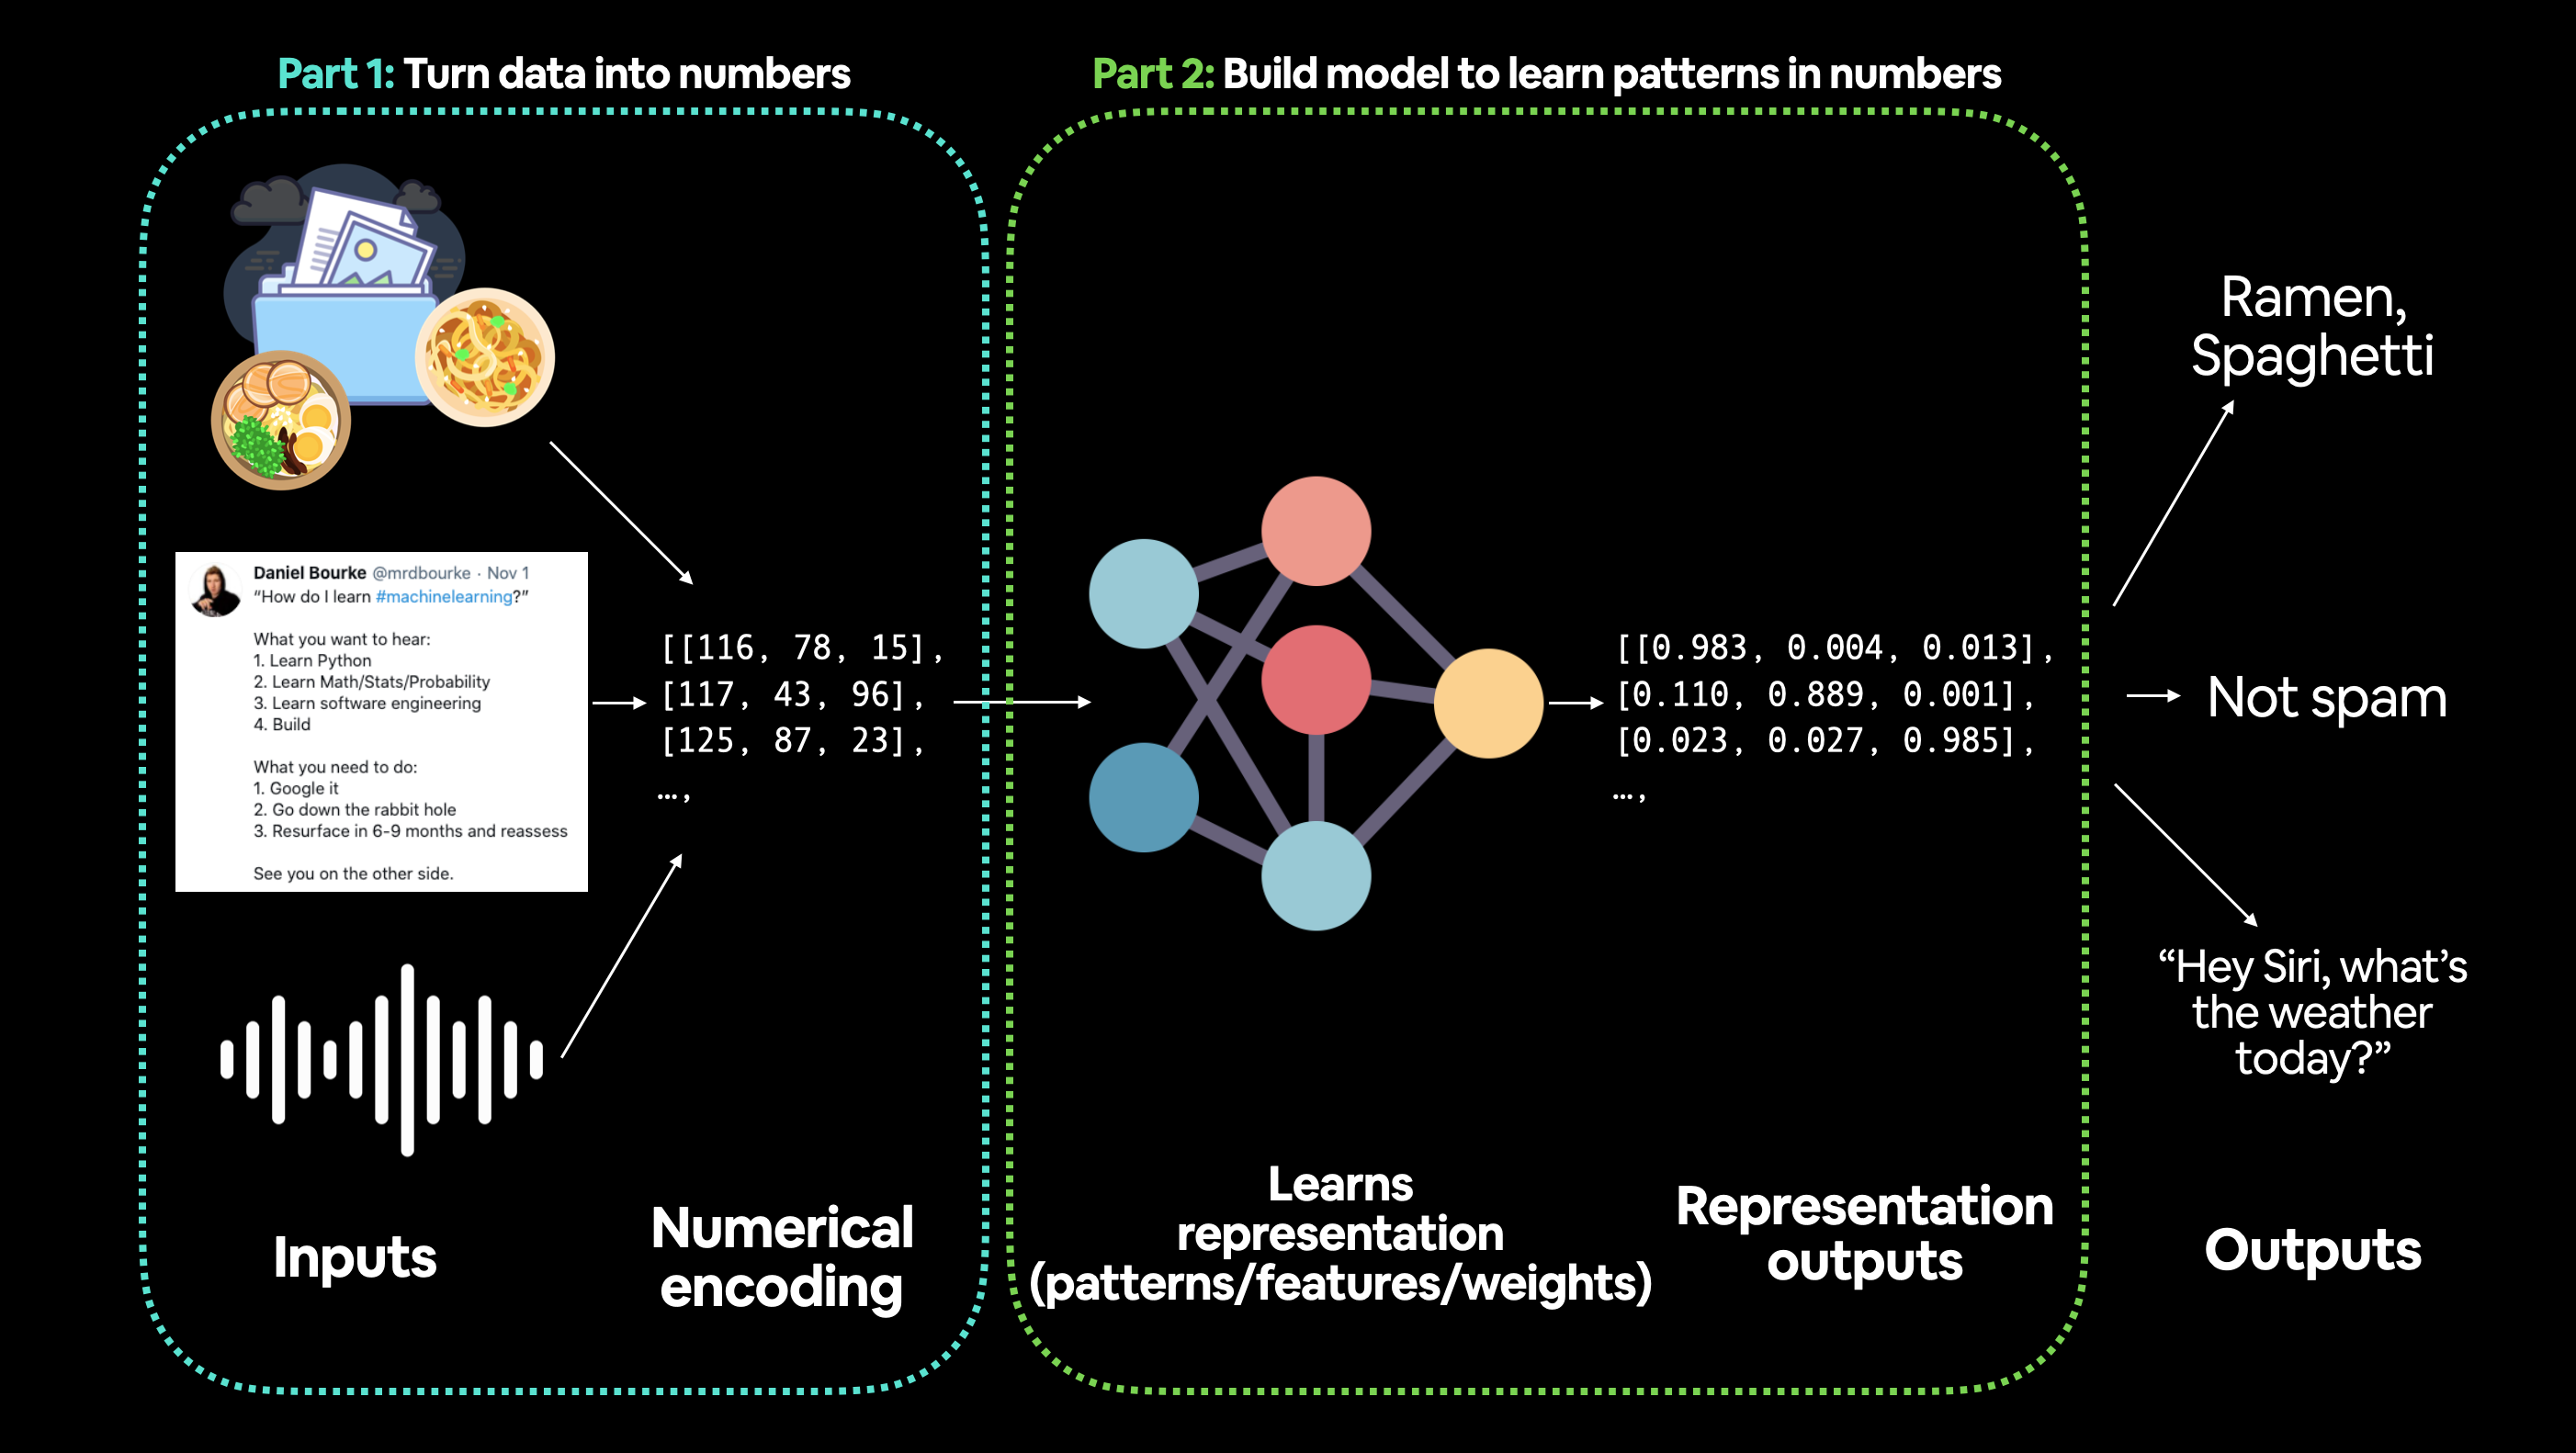

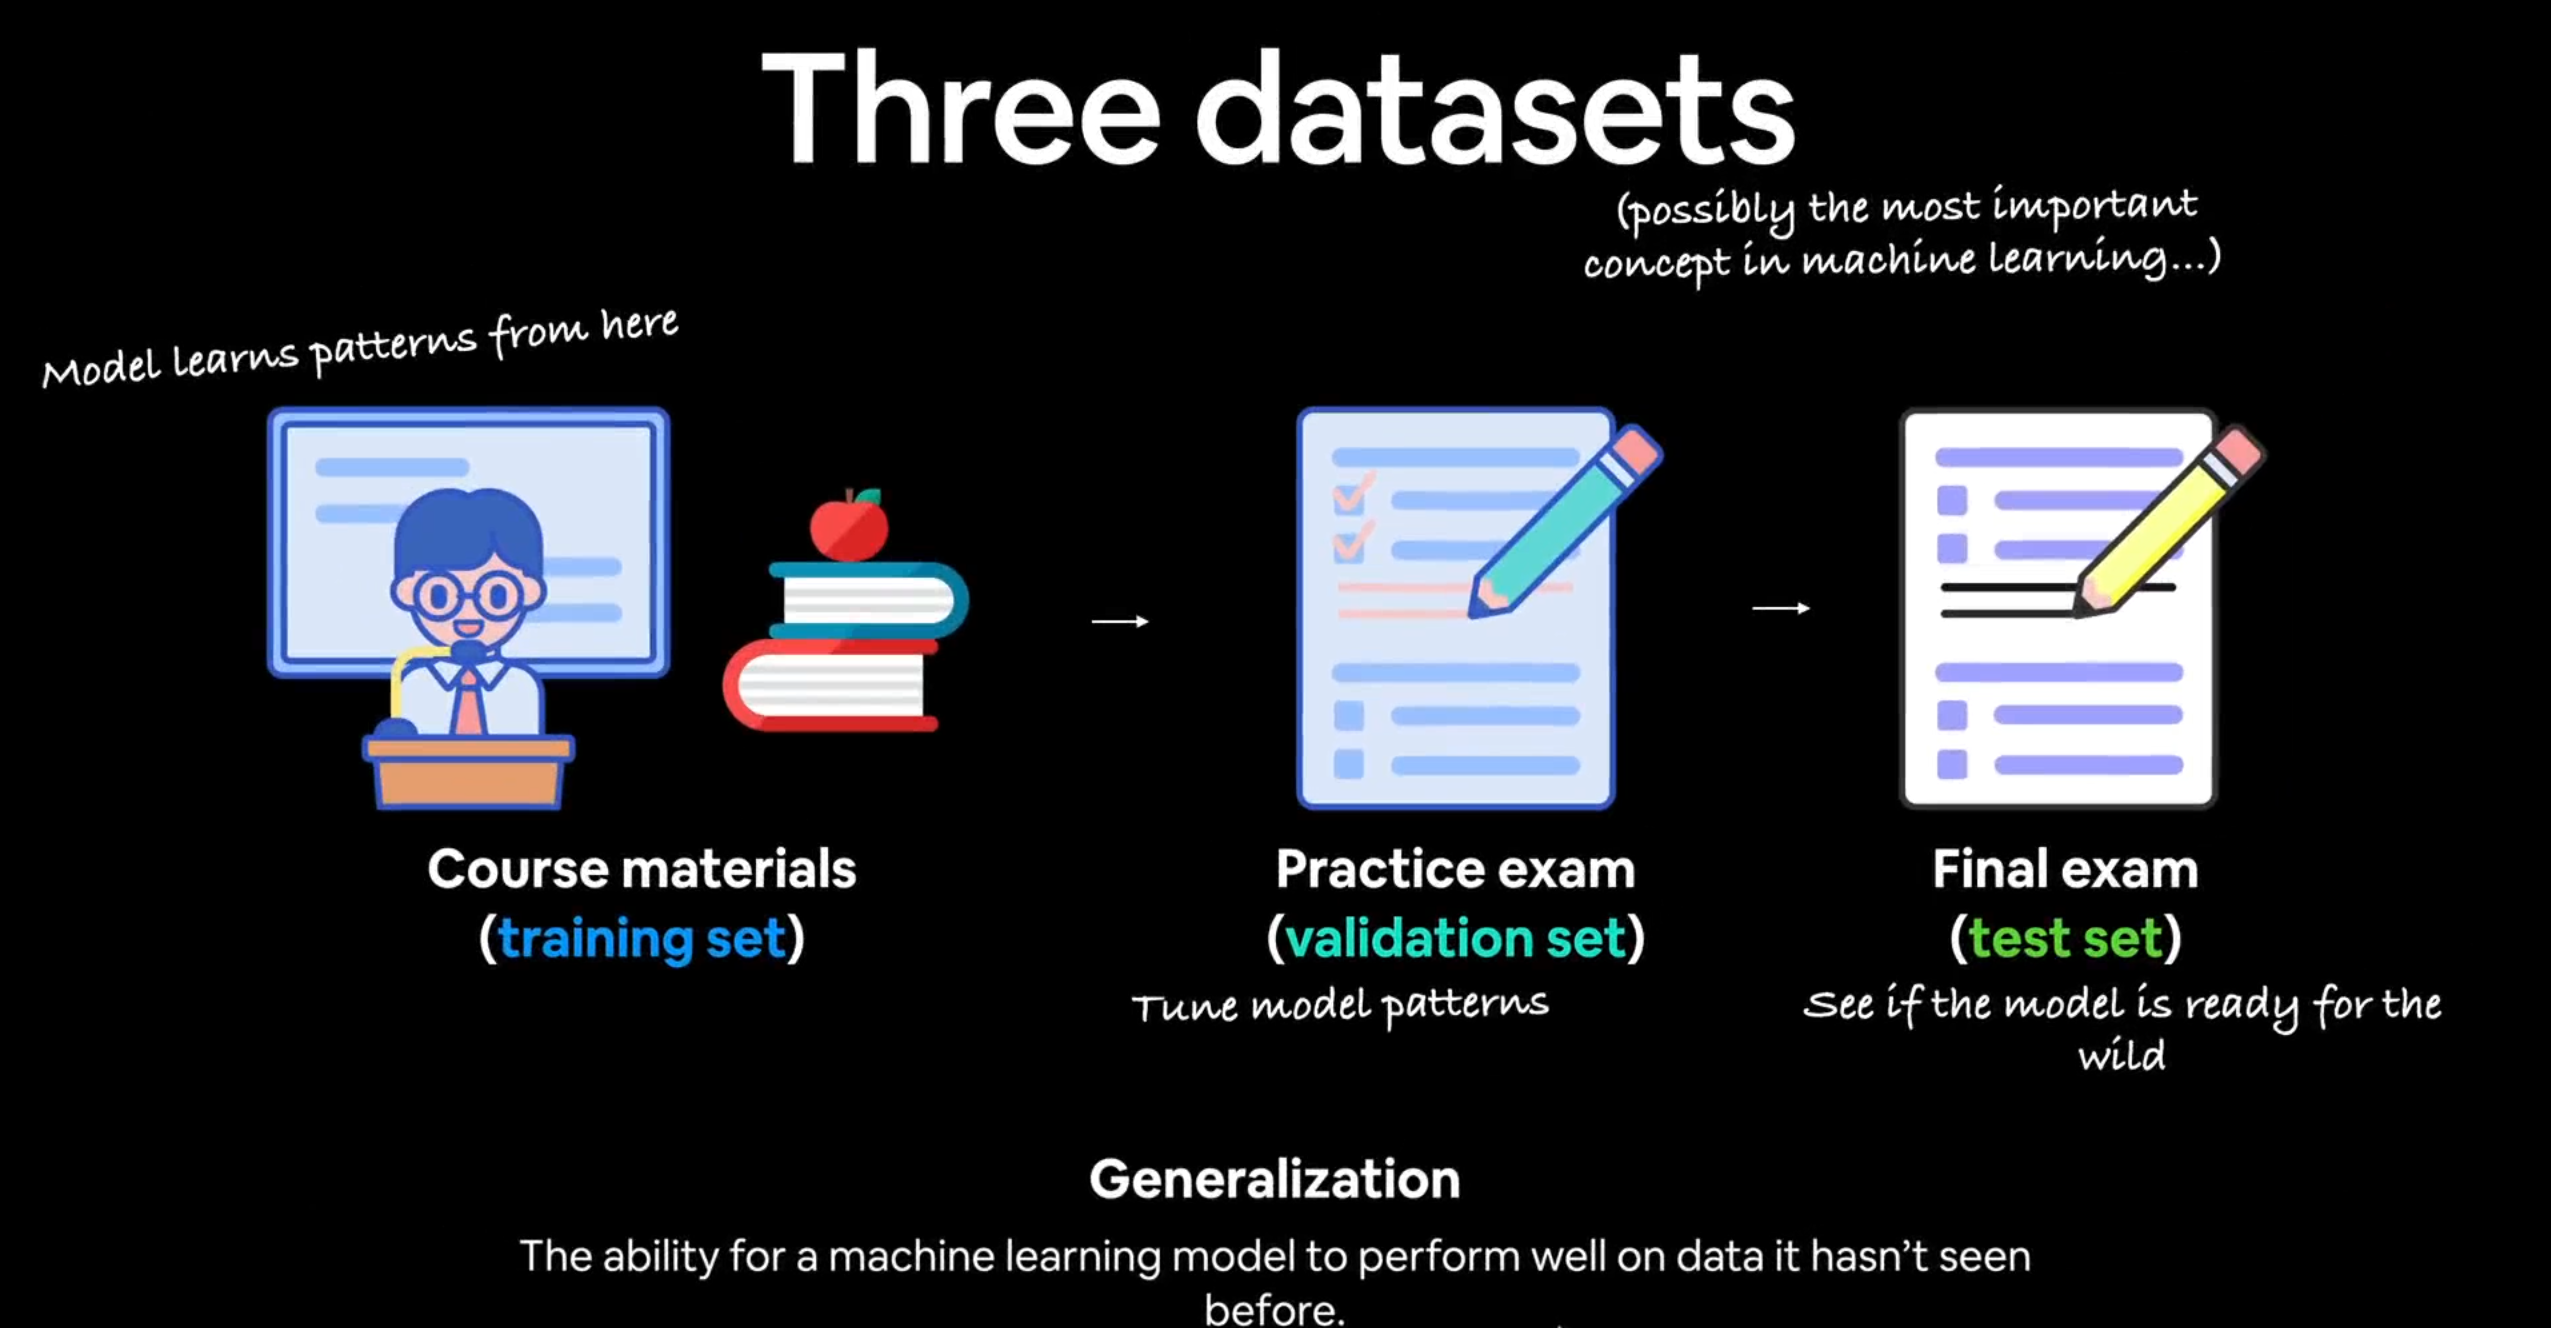

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
X = torch.linspace(1, 2, 30, device=device).unsqueeze(dim=1)
y = 0.29 * X + 0.28  # y = a*X + b

In [4]:
y[:10]

tensor([[0.5700],
        [0.5800],
        [0.5900],
        [0.6000],
        [0.6100],
        [0.6200],
        [0.6300],
        [0.6400],
        [0.6500],
        [0.6600]])

### Split the data into train and test

In [5]:
split = int(0.7 * len(X))  # 70 % of the Data
split

21

In [6]:
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

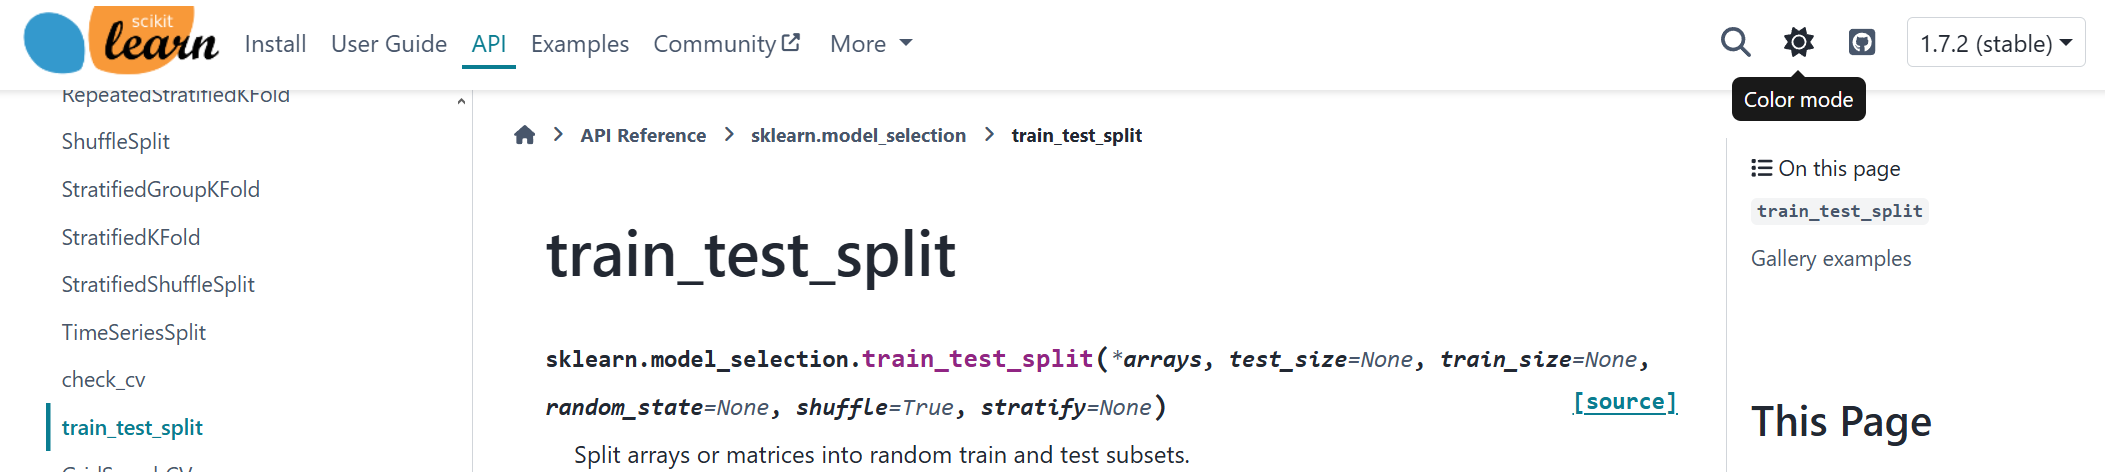

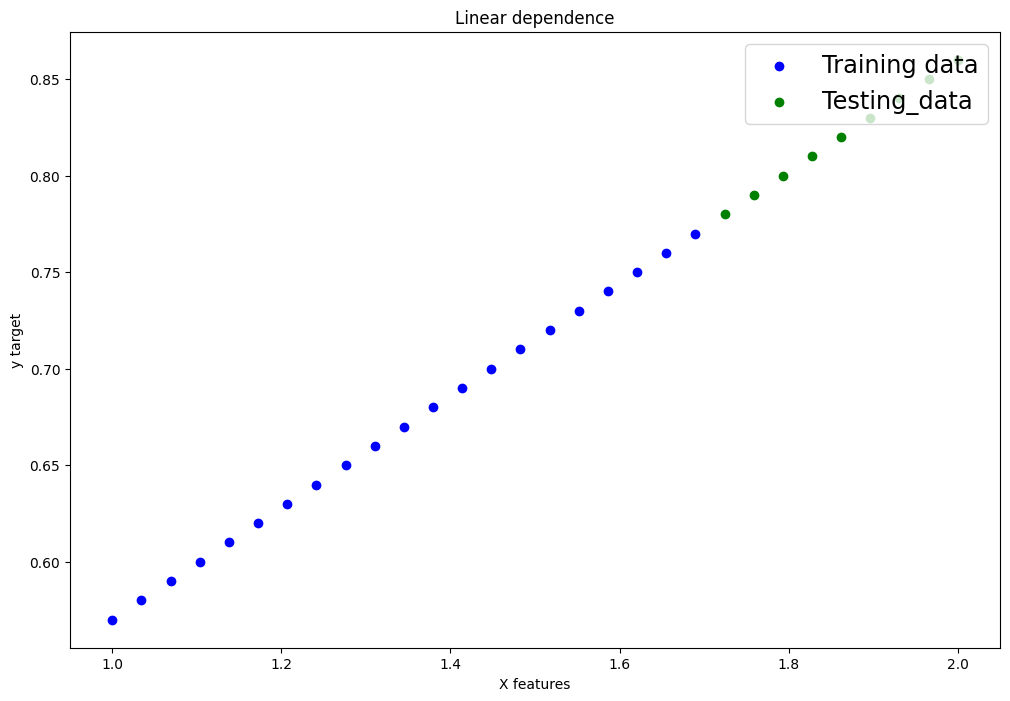

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.scatter(X_train.cpu(), y_train.cpu(), c='b', label='Training data')
plt.scatter(X_test.cpu(), y_test.cpu(), c='g', label='Testing_data')
plt.xlabel('X features')
plt.ylabel('y target')
plt.title('Linear dependence')
plt.legend(loc=1, fontsize='xx-large')
plt.show()

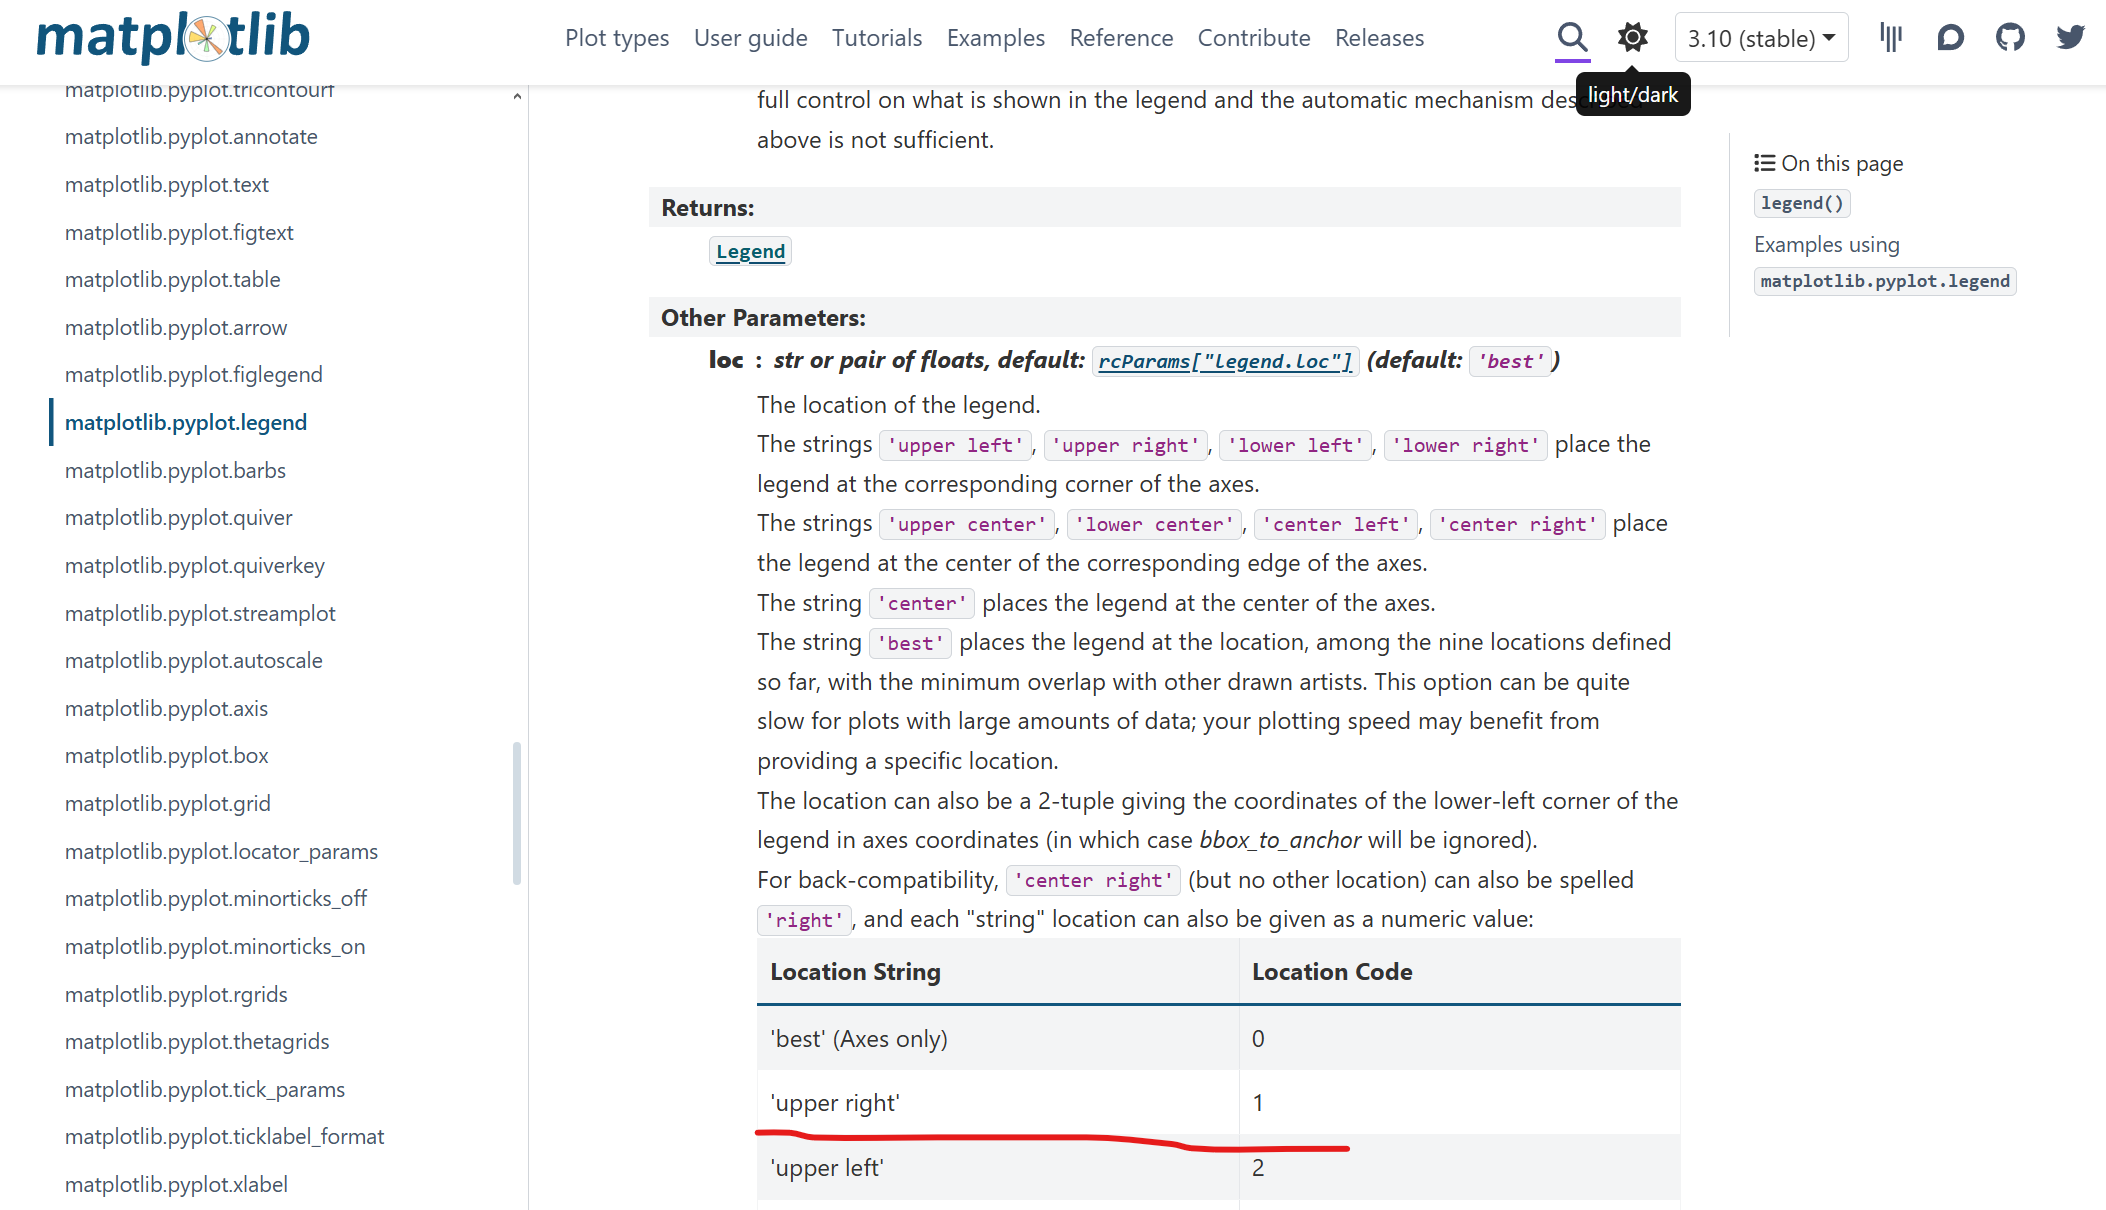

In [8]:
class SimpleLinReg(nn.Module):
    def __init__(self):
        super().__init__()
        # .randn(size=1) means tensor with 1 element
        self.weights = nn.Parameter(data=torch.randn(1, requires_grad=True, dtype=torch.float16))
        self.bias = nn.Parameter(data=torch.randn(1, requires_grad=True, dtype=torch.float16))

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """Define the computation in the model."""
        return self.weights * X + self.bias

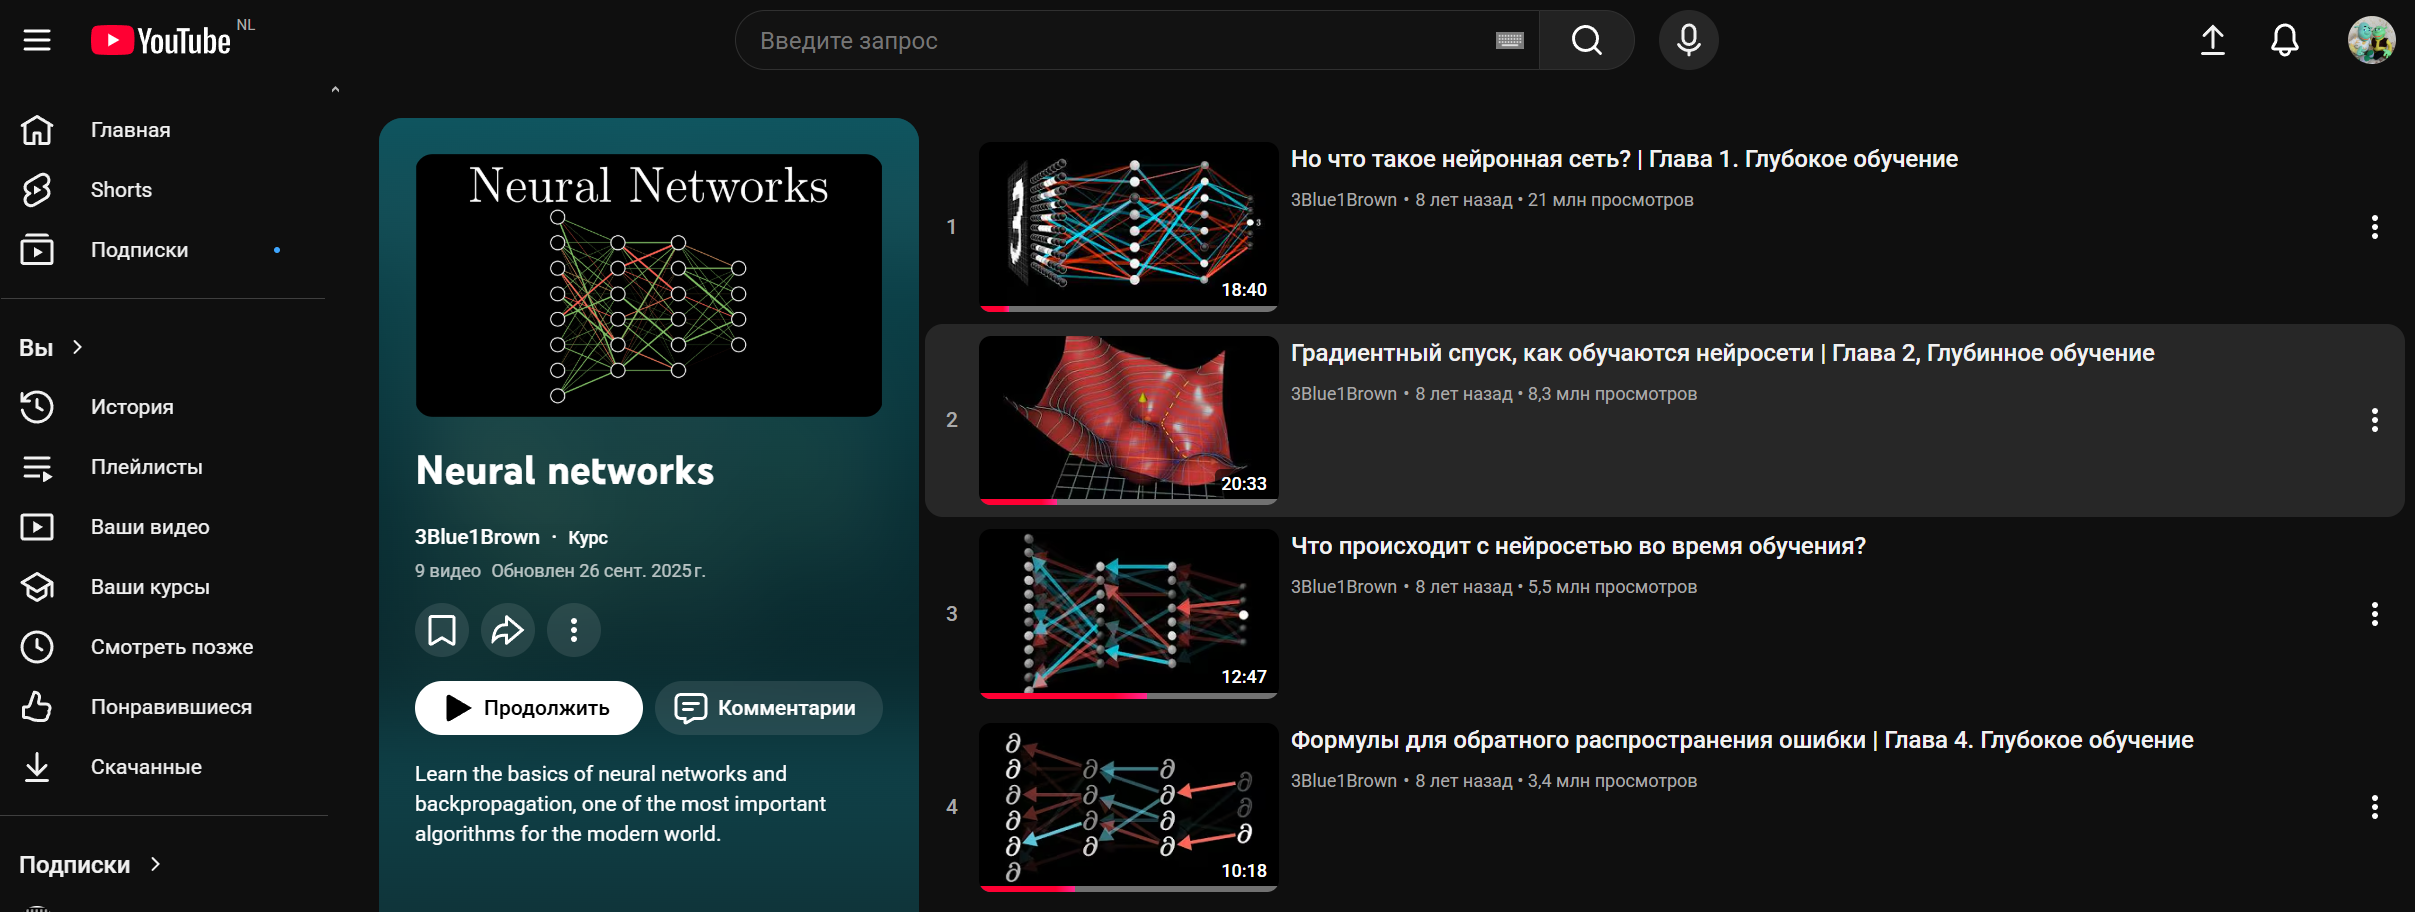

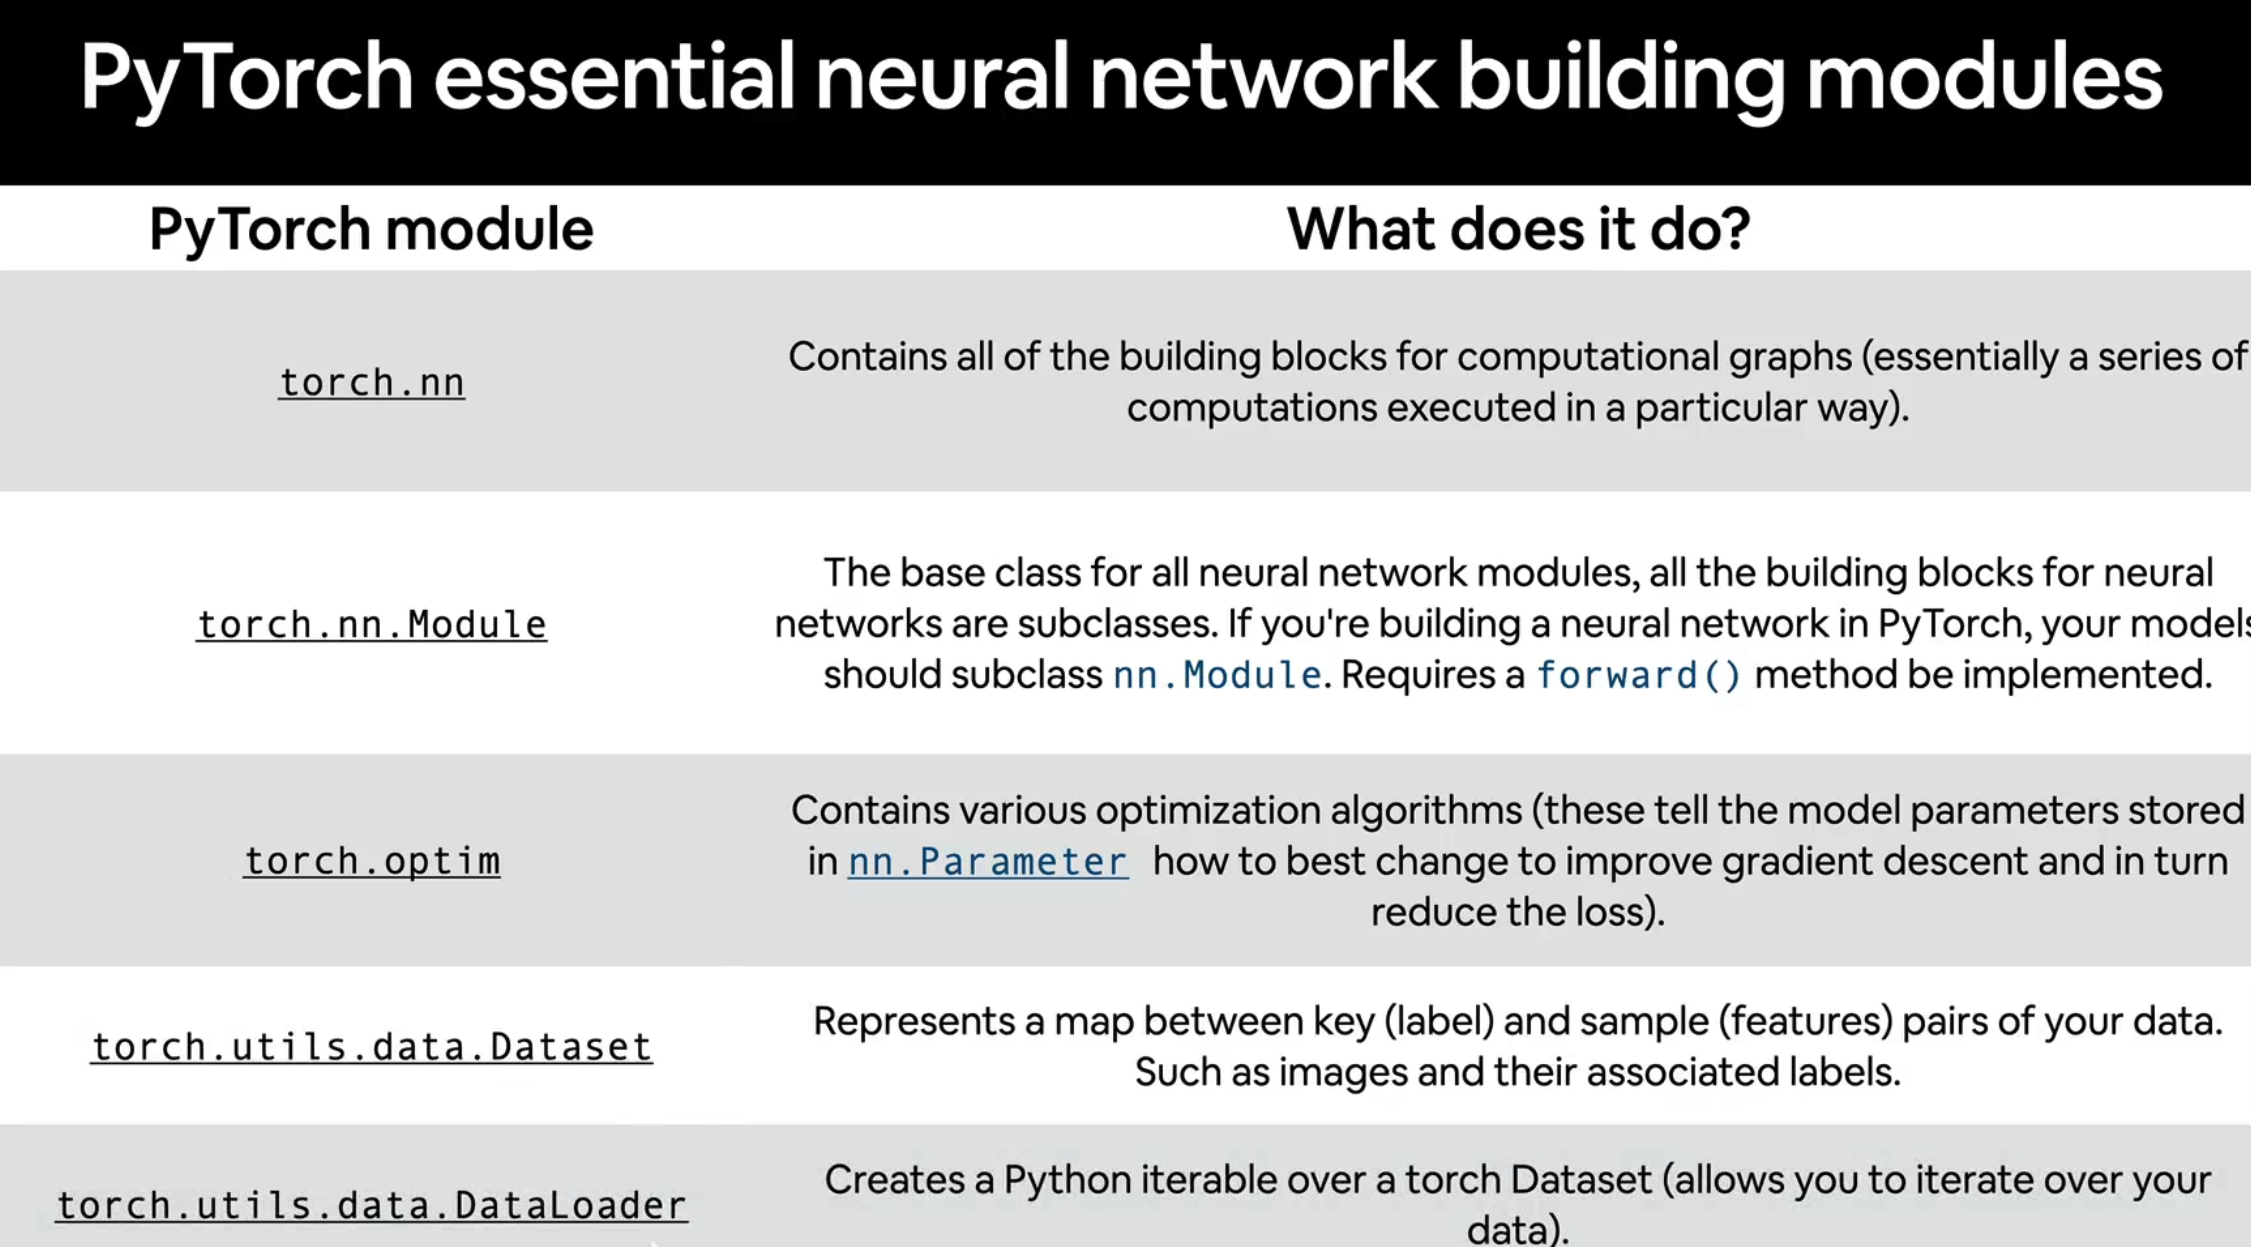

In [9]:
torch.manual_seed(29)

sim_lin_reg = SimpleLinReg()
list(sim_lin_reg.parameters())

[Parameter containing:
 tensor([1.1475], dtype=torch.float16, requires_grad=True),
 Parameter containing:
 tensor([-0.1417], dtype=torch.float16, requires_grad=True)]

### Most ML models start training with random parameters

`torch.nn.Module.state_dict()`

`y = 0.29 * X + 0.28`

In [10]:
sim_lin_reg.state_dict()

OrderedDict([('weights', tensor([1.1475], dtype=torch.float16)),
             ('bias', tensor([-0.1417], dtype=torch.float16))])

In [11]:
weight, bias = (0.7, 0.3)

In [12]:
# Check .forward() method
input_0 = torch.tensor([0.7, 0.3])
sim_lin_reg.forward(X=input_0)

tensor([0.6615, 0.2025], grad_fn=<AddBackward0>)

In [13]:
with torch.inference_mode():
    y_preds = sim_lin_reg.to(device=device).forward(X=X_test)

y_preds

tensor([[1.8367],
        [1.8762],
        [1.9158],
        [1.9554],
        [1.9949],
        [2.0345],
        [2.0741],
        [2.1136],
        [2.1532]])

In [14]:
from typing import Optional

def plot_predictions(pred: torch.Tensor, test: torch.Tensor, title: Optional[str] = None) -> None:
    # Conver from cuda device to cpu
    pred = pred.cpu()
    test = test.to(device="cpu")
    
    plt.plot(test, "*b", label="predicted data")
    plt.plot(pred, "*r", label="test data")


    plt.title(title)
    plt.grid()
    plt.legend(loc="upper left")
    plt.show()

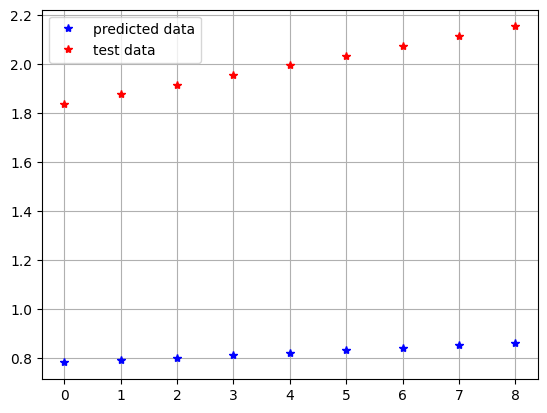

In [15]:
plot_predictions(y_preds, y_test)

In [16]:
torch.equal(y_preds, y_test)

False

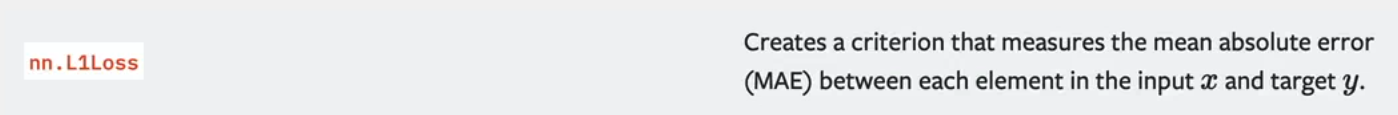

#### Loss function and optimizer

In [17]:
loss_fn = nn.L1Loss()  # MAE loss function
loss_fn

L1Loss()

In [18]:
from torch import optim

optimizer = optim.SGD(params=sim_lin_reg.parameters(), lr=1e-2)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

### Training loop

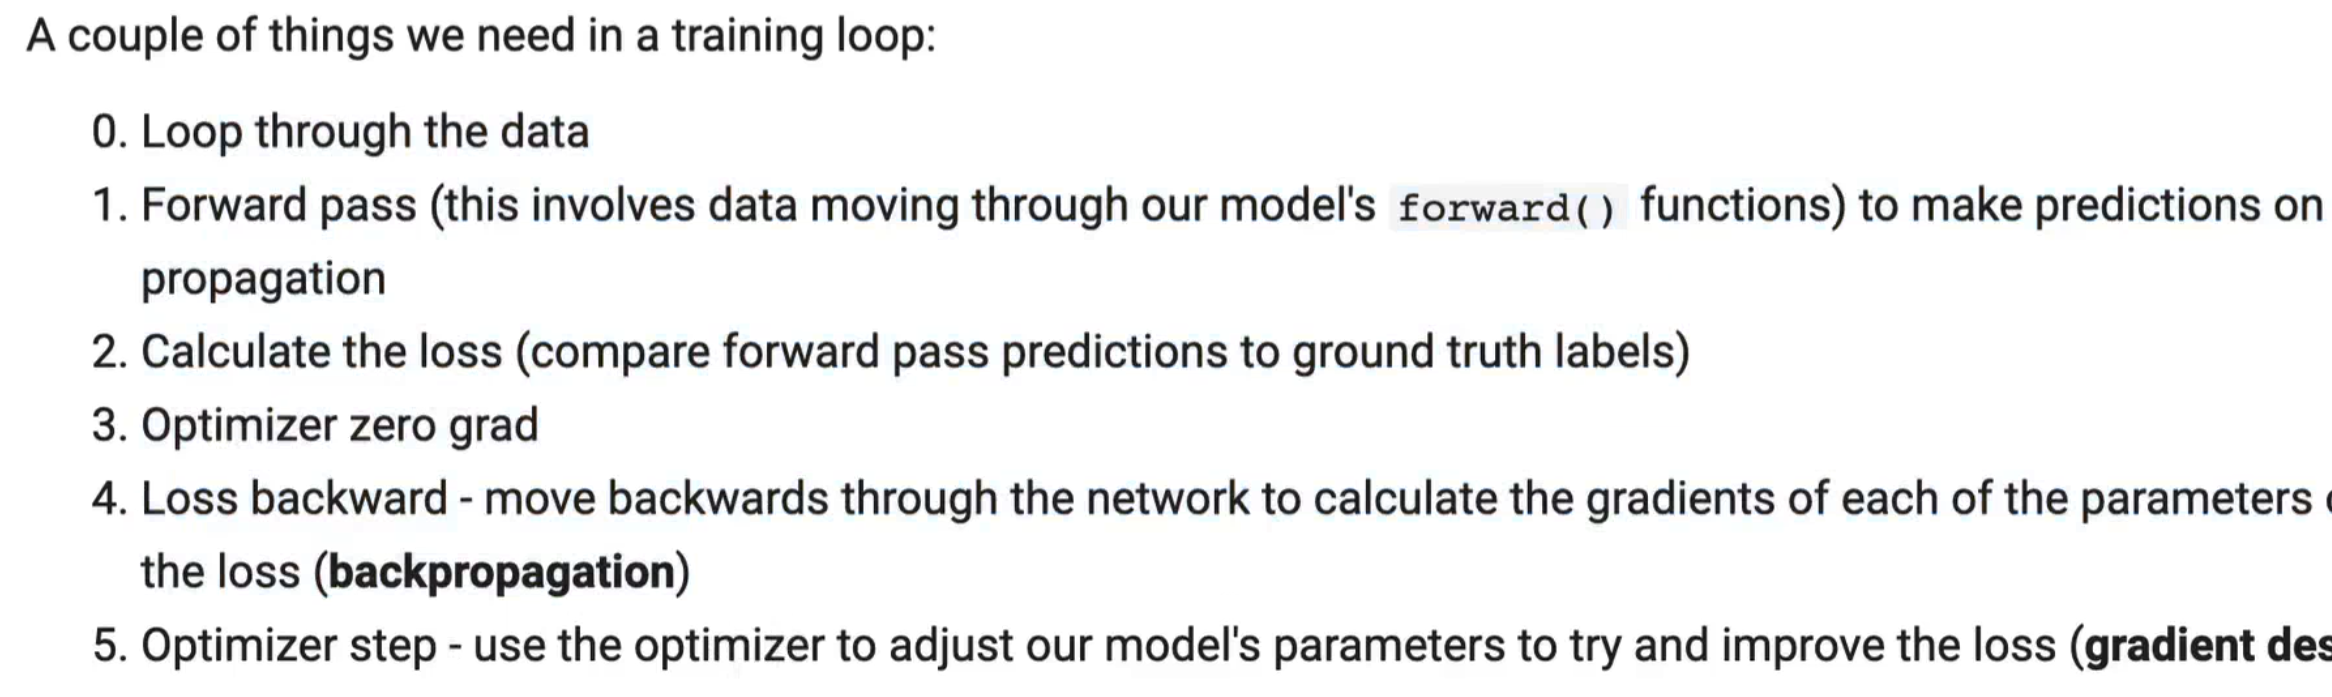

In [19]:
!pip install tqdm


[notice] A new release of pip is available: 25.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from tqdm import tqdm

In [21]:
sim_lin_reg.state_dict()

OrderedDict([('weights', tensor([1.1475], dtype=torch.float16)),
             ('bias', tensor([-0.1417], dtype=torch.float16))])

In [22]:
torch.manual_seed(29)
epochs = 500

# Tracking experiments
epoch_values: list[int] = []
loss_values: list[float] = []
test_loss_values: list[float] = []

for epoch in tqdm(range(1, epochs + 1)):
    # Training mode (set parameters to require gradients)
    sim_lin_reg.train()   
    y_pred = sim_lin_reg(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Test mode
    sim_lin_reg.eval()
    with torch.inference_mode():  # Turn off gradients tracking
        test_pred = sim_lin_reg(X_test)
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        # TODO: replace print by logging   
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

    epoch_values.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)

 48%|████▊     | 242/500 [00:00<00:00, 1066.57it/s]

Epoch: 100 | Loss: 0.08219034969806671 | Test loss: 0.21754713356494904
Epoch: 200 | Loss: 0.07097191363573074 | Test loss: 0.18794721364974976
Epoch: 300 | Loss: 0.05975347384810448 | Test loss: 0.1583472639322281


100%|██████████| 500/500 [00:00<00:00, 1097.96it/s]

Epoch: 400 | Loss: 0.04858443886041641 | Test loss: 0.12770970165729523
Epoch: 500 | Loss: 0.03746351599693298 | Test loss: 0.0977003425359726


### Converts list of Tensors (cuda:0) to the lists of float for matplotlib

In [23]:
loss_values = [loss.item() for loss in loss_values]
test_loss_values = [loss.item() for loss in test_loss_values]

Text(0.5, 1.0, 'Training process')

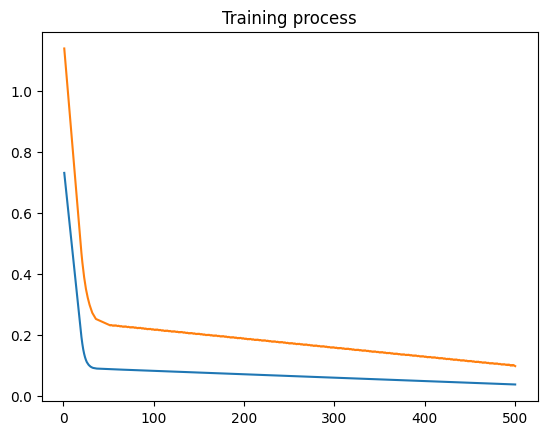

In [24]:
plt.plot(epoch_values, loss_values, label="Train loss")
plt.plot(epoch_values, test_loss_values, label="Test loss")
plt.title("Training process")

In [25]:
print(loss)
sim_lin_reg.state_dict()

tensor(0.0375, grad_fn=<MeanBackward0>)


OrderedDict([('weights', tensor([0.4944], dtype=torch.float16)),
             ('bias', tensor([-0.0029], dtype=torch.float16))])

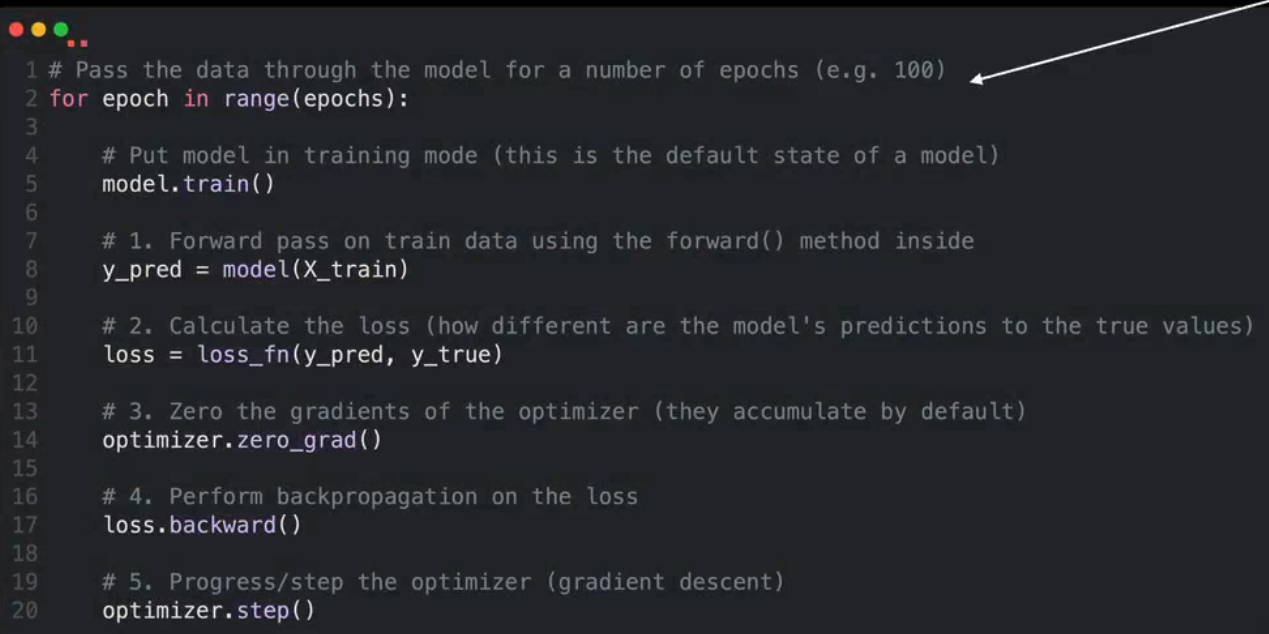

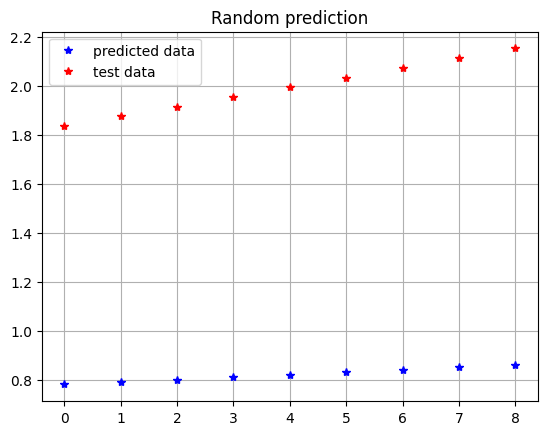

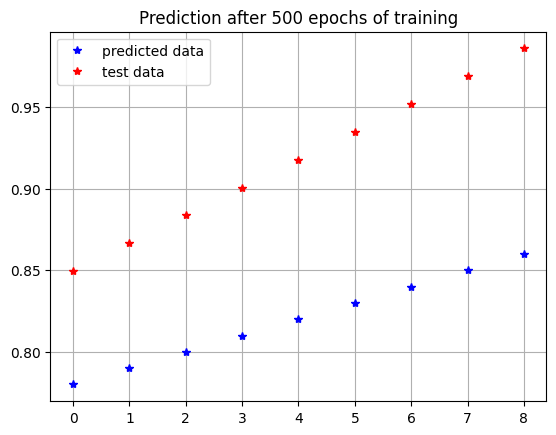

In [26]:
with torch.inference_mode():
    y_preds_new = sim_lin_reg(X_test)

plot_predictions(y_preds, y_test, title="Random prediction")
plot_predictions(y_preds_new, y_test, title=f"Prediction after {epochs} epochs of training")

### Saving the model

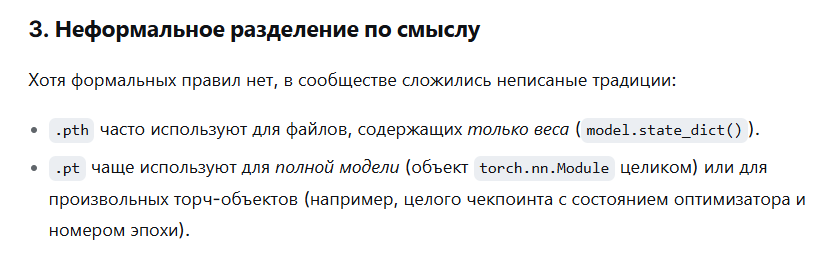

In [27]:
sim_lin_reg.state_dict()

OrderedDict([('weights', tensor([0.4944], dtype=torch.float16)),
             ('bias', tensor([-0.0029], dtype=torch.float16))])

In [28]:
# Create path for saveng the model
from pathlib import Path

model_path = Path('../../models/')
model_path.mkdir(parents=True, exist_ok=True)
model_name = 'sim_lin_reg.pth'
model_save_path = model_path / model_name

In [29]:
torch.save(obj=sim_lin_reg.state_dict(), f=model_save_path)

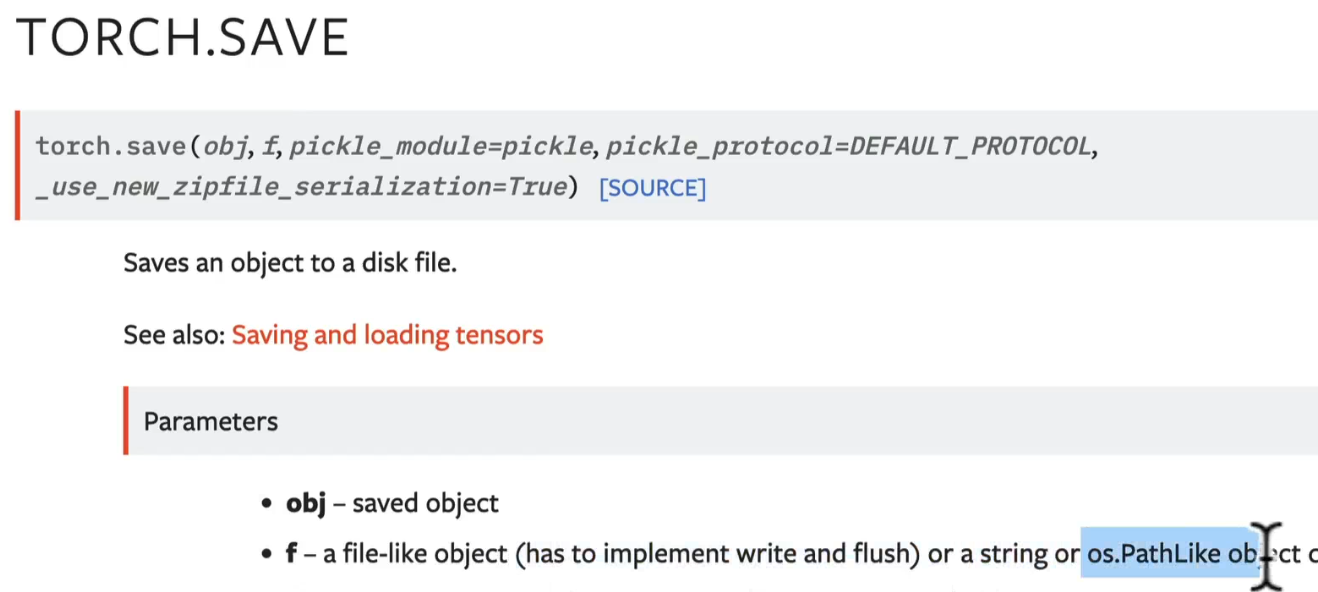